##BÀI ÔN TẬP: PHÂN TÍCH DỮ LIỆU & HỌC SÂU

**PHẦN 1: TIỀN XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU**

**Câu 1: Nạp và Khám phá dữ liệu**

Sử dụng thư viện seaborn, hãy tải bộ dữ liệu tích hợp sẵn có tên là 'titanic' (tập dữ liệu về hành
khách trên tàu Titanic).

In ra 5 dòng đầu tiên của tập dữ liệu.

In ra thông tin tổng quan của dữ liệu (sử dụng hàm info()) để xem kiểu dữ liệu và số lượng
giá trị Non-Null của từng cột.


In [ ]:
import pandas as pd
import seaborn as sns

# Tải dữ liệu Titanic
df = sns.load_dataset("titanic")

# Hiển thị 5 dòng đầu
display(df.head())

# Thông tin tổng quan
df.info()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**Câu 2: Xử lý giá trị khuyết**

Tập dữ liệu 'titanic' có một số cột chứa giá trị khuyết (Missing Values).

Đếm số lượng giá trị khuyết ở mỗi cột.

Cột 'deck' có quá nhiều giá trị khuyết. Hãy viết lệnh xóa hoàn toàn cột này khỏi DataFrame.

Cột 'age' (tuổi) có một số giá trị khuyết. Hãy điền các giá trị khuyết này bằng Trung bình
(Mean) tuổi của tất cả hành khách.


In [ ]:
# Đếm số lượng giá trị khuyết ở mỗi cột
print("Số lượng giá trị khuyết:")
print(df.isnull().sum())

# Xóa cột deck
df = df.drop(columns=["deck"])

# Tính tuổi trung bình
mean_age = df["age"].mean()

# Điền giá trị khuyết của age bằng tuổi trung bình
df["age"] = df["age"].fillna(mean_age)

# Kiểm tra lại
print("\nSau khi xử lý:")
print(df.isnull().sum())

Số lượng giá trị khuyết:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Sau khi xử lý:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


**Câu 3: Phân tích và Trực quan hóa**

Sử dụng matplotlib và seaborn để thực hiện các yêu cầu sau:

Vẽ biểu đồ cột (Bar plot hoặc Count plot) thể hiện số lượng hành khách sống sót (cột
'survived') phân chia theo giới tính (cột 'sex').

Vẽ biểu đồ phân bố (Histogram hoặc KDE) thể hiện phân bố độ tuổi ('age') của các hành khách
trên tàu.

Tính toán ma trận tương quan giữa các biến số (chỉ lấy các cột có kiểu dữ liệu dạng số như
'survived', 'pclass', 'age', 'fare') và vẽ Heatmap biểu diễn ma trận đó.


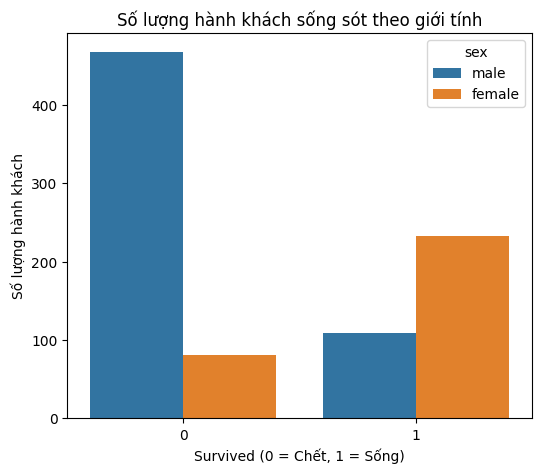

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="survived",
    hue="sex"
)

plt.title("Số lượng hành khách sống sót theo giới tính")
plt.xlabel("Survived (0 = Chết, 1 = Sống)")
plt.ylabel("Số lượng hành khách")

plt.show()

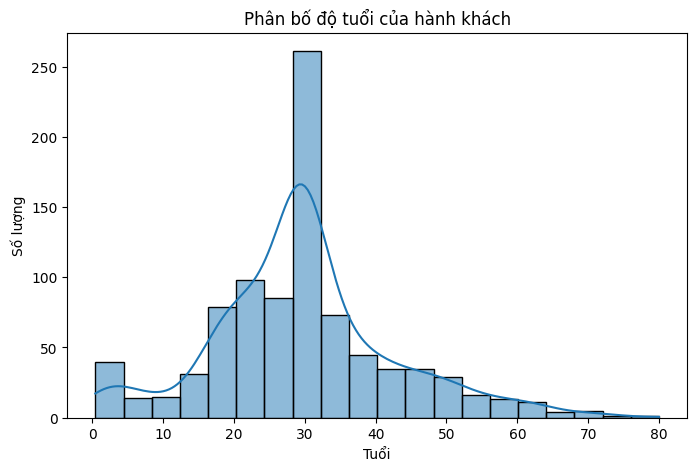

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Phân bố độ tuổi của hành khách")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")

plt.show()

          survived    pclass       age      fare
survived  1.000000 -0.338481 -0.069809  0.257307
pclass   -0.338481  1.000000 -0.331339 -0.549500
age      -0.069809 -0.331339  1.000000  0.091566
fare      0.257307 -0.549500  0.091566  1.000000


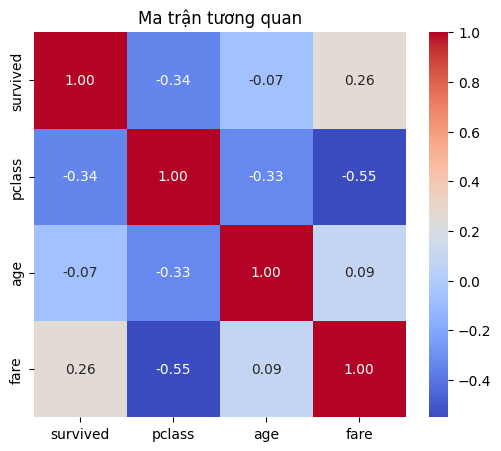

In [ ]:
# Chọn các cột số
corr = df[["survived", "pclass", "age", "fare"]].corr()

print(corr)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Ma trận tương quan")

plt.show()

**Câu 4: Mã hóa dữ liệu**

Để chuẩn bị dữ liệu cho mô hình học máy:

Sử dụng kỹ thuật Label Encoding (hoặc map dictionary) để chuyển đổi cột 'sex' ('male',
'female') thành dạng số (0, 1).

Sử dụng kỹ thuật One-Hot Encoding (pd.get_dummies) cho cột 'embarked' (Cảng lên tàu) và
gộp vào DataFrame chính.

In [ ]:
# Label Encoding cho cột 'sex'
df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

# One-Hot Encoding cho cột 'embarked'
embarked_encoded = pd.get_dummies(
    df["embarked"],
    prefix="embarked"
)

# Gộp các cột mới vào DataFrame
df = pd.concat(
    [df, embarked_encoded],
    axis=1
)

# Kiểm tra kết quả
display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,False,False,True
1,1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,True,False,False
2,1,3,1,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,0,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,False,False,True


**PHẦN 2: XÂY DỰNG MÔ HÌNH HỌC SÂU CƠ BẢN**

**Câu 5: Chuẩn bị dữ liệu cho Học sâu**

Chúng ta sẽ dự đoán khả năng sống sót ('survived') dựa trên 3 đặc trưng: 'pclass' (Hạng vé),
'sex' (Giới tính đã mã hóa), và 'age' (Tuổi đã điền khuyết).

Tạo biến X chứa 3 cột đặc trưng trên, và biến y chứa cột 'survived'.

Sử dụng train_test_split từ thư viện sklearn để chia dữ liệu thành tập huấn luyện (train) và
tập kiểm thử (test) với tỷ lệ 80% - 20%.
(Tùy chọn nhưng khuyến khích): Chuẩn hóa (Scale) tập X_train và X_test bằng StandardScaler

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tạo biến đặc trưng (X) và nhãn (y)
X = df[["pclass", "sex", "age"]]
y = df["survived"]

# Chia dữ liệu train/test theo tỷ lệ 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Chuẩn hóa dữ liệu (khuyến khích)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Kiểm tra kích thước dữ liệu
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 3)
X_test : (179, 3)
y_train: (712,)
y_test : (179,)


**Câu 6: Xây dựng mạng Nơ-ron nhân tạo (ANN)**

Sử dụng thư viện TensorFlow / Keras để xây dựng mô hình phân loại nhị phân (sống hoặc
chết).

1. Khởi tạo một mô hình Sequential().

2. Thêm một lớp ẩn (Dense layer) với 16 nơ-ron và hàm kích hoạt 'relu'. Nhớ cấu hình
input_shape phù hợp với số lượng đặc trưng đầu vào (3 đặc trưng).

3. Thêm lớp đầu ra (Output layer) với 1 nơ-ron và hàm kích hoạt 'sigmoid' (vì đây là bài toán
phân loại nhị phân).

4. Compile mô hình với optimizer là 'adam', loss function là 'binary_crossentropy', và
metrics là ['accuracy'].

5. Huấn luyện mô hình (fit) với tập train trong 20 epochs. In ra kết quả đánh giá (evaluate) trên tập
test.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Khởi tạo mô hình ANN
model = Sequential([
    Dense(16, activation="relu", input_shape=(3,)),
    Dense(1, activation="sigmoid")
])

# Hiển thị cấu trúc mô hình
model.summary()

# Biên dịch mô hình
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Huấn luyện mô hình
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Đánh giá trên tập kiểm thử
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6151 - loss: 0.6664 - val_accuracy: 0.7063 - val_loss: 0.6263
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6538 - loss: 0.6376 - val_accuracy: 0.7133 - val_loss: 0.5968
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7047 - loss: 0.6134 - val_accuracy: 0.7413 - val_loss: 0.5694
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7241 - loss: 0.5911 - val_accuracy: 0.7552 - val_loss: 0.5477
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7329 - loss: 0.5732 - val_accuracy: 0.7762 - val_loss: 0.5267
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7381 - loss: 0.5562 - val_accuracy: 0.7832 - val_loss: 0.5093
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7452 - loss: 0.5421 - val_accuracy: 0.7832 - val_loss: 0.4938
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7575 - loss: 0.5297 - val_accuracy: 0.7622 - val_loss